<a href="https://colab.research.google.com/github/kvssri/online-tihiitg/blob/main/task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Underwater-Image-Data-set-main.zip to Underwater-Image-Data-set-main.zip


In [2]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/project_data')

print("Main ZIP extracted successfully!")

Main ZIP extracted successfully!


In [3]:
import glob

seven_zip_files = glob.glob('/content/project_data/**/*.7z', recursive=True)

print("Total .7z files found:", len(seven_zip_files))

for file in seven_zip_files:
    print(file)

Total .7z files found: 8
/content/project_data/Underwater-Image-Data-set-main/epoch_00100.7z
/content/project_data/Underwater-Image-Data-set-main/epoch_0115.7z
/content/project_data/Underwater-Image-Data-set-main/epoch_0120.7z
/content/project_data/Underwater-Image-Data-set-main/epoch_0096.7z
/content/project_data/Underwater-Image-Data-set-main/epoch_100.7z
/content/project_data/Underwater-Image-Data-set-main/epoch_0135.7z
/content/project_data/Underwater-Image-Data-set-main/epoch_0110.7z
/content/project_data/Underwater-Image-Data-set-main/epoch_0100.7z


In [4]:
!apt-get install p7zip-full -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


In [5]:
import os
import glob

seven_zip_files = glob.glob('/content/project_data/**/*.7z', recursive=True)

for file in seven_zip_files:
    output_folder = file.replace('.7z', '')
    os.makedirs(output_folder, exist_ok=True)

    print("Extracting:", file)
    !7z x "{file}" -o"{output_folder}" -y

print("All .7z files extracted!")

Extracting: /content/project_data/Underwater-Image-Data-set-main/epoch_00100.7z

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs AMD EPYC 7B12 (830F10),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/project_data/Underwater-Image-Data-set-main/                                                               1 file, 31290555 bytes (30 MiB)

Extracting archive: /content/project_data/Underwater-Image-Data-set-main/epoch_00100.7z
--
Path = /content/project_data/Underwater-Image-Data-set-main/epoch_00100.7z
Type = 7z
Physical Size = 31290555
Headers Size = 8080
Method = LZMA:23
Solid = +
Blocks = 1

  0%      8% - epoch_0100/img 100_gen.png                                  22% 108 - e

In [6]:
for file in seven_zip_files:

    output_folder = file[:-3]

    os.makedirs(output_folder, exist_ok=True)

    print("Extracting:", file)

    os.system(
        f'7z x "{file}" -o"{output_folder}" -y > /dev/null'
    )

print("All files extracted successfully!")

Extracting: /content/project_data/Underwater-Image-Data-set-main/epoch_00100.7z
Extracting: /content/project_data/Underwater-Image-Data-set-main/epoch_0115.7z
Extracting: /content/project_data/Underwater-Image-Data-set-main/epoch_0120.7z
Extracting: /content/project_data/Underwater-Image-Data-set-main/epoch_0096.7z
Extracting: /content/project_data/Underwater-Image-Data-set-main/epoch_100.7z
Extracting: /content/project_data/Underwater-Image-Data-set-main/epoch_0135.7z
Extracting: /content/project_data/Underwater-Image-Data-set-main/epoch_0110.7z
Extracting: /content/project_data/Underwater-Image-Data-set-main/epoch_0100.7z
All files extracted successfully!


In [7]:
image_extensions = (
    '.jpg', '.jpeg', '.png',
    '.bmp', '.webp',
    '.tif', '.tiff'
)

image_files = []

for root, dirs, files in os.walk('/content/project_data'):

    for file in files:

        if file.lower().endswith(image_extensions):

            image_files.append(
                os.path.join(root, file)
            )

print("Total images found:", len(image_files))

for img in image_files[:5]:
    print(img)

Total images found: 3694
/content/project_data/Underwater-Image-Data-set-main/epoch_00100/epoch_0100/img 30_input.png
/content/project_data/Underwater-Image-Data-set-main/epoch_00100/epoch_0100/img 44_gen.png
/content/project_data/Underwater-Image-Data-set-main/epoch_00100/epoch_0100/img 98_input.png
/content/project_data/Underwater-Image-Data-set-main/epoch_00100/epoch_0100/img 138_input.png
/content/project_data/Underwater-Image-Data-set-main/epoch_00100/epoch_0100/img 59_input.png


In [8]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from sklearn.model_selection import train_test_split

In [9]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

train_files, temp_files = train_test_split(
    image_files,
    test_size=0.30,
    random_state=SEED
)

val_files, test_files = train_test_split(
    temp_files,
    test_size=0.50,
    random_state=SEED
)

print("Training images:", len(train_files))
print("Validation images:", len(val_files))
print("Testing images:", len(test_files))

Training images: 2585
Validation images: 554
Testing images: 555


In [10]:
train_set = set(train_files)
val_set = set(val_files)
test_set = set(test_files)

print(
    "Train-Val overlap:",
    len(train_set.intersection(val_set))
)

print(
    "Train-Test overlap:",
    len(train_set.intersection(test_set))
)

print(
    "Val-Test overlap:",
    len(val_set.intersection(test_set))
)

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [11]:
IMAGE_SIZE = 256

basic_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [12]:
train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [13]:
eval_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [14]:
class UnderwaterDataset(Dataset):

    def __init__(self, image_paths, transform=None):

        self.image_paths = image_paths
        self.transform = transform


    def __len__(self):

        return len(self.image_paths)


    def __getitem__(self, index):

        image_path = self.image_paths[index]

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform:

            image = self.transform(
                image
            )

        return image

In [15]:
class UnderwaterDataset(Dataset):

    def __init__(self, image_paths, transform=None):

        self.image_paths = image_paths
        self.transform = transform


    def __len__(self):

        return len(self.image_paths)


    def __getitem__(self, index):

        image_path = self.image_paths[index]

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform:

            image = self.transform(
                image
            )

        return image

In [16]:
train_dataset = UnderwaterDataset(
    train_files,
    transform=train_transform
)

val_dataset = UnderwaterDataset(
    val_files,
    transform=eval_transform
)

test_dataset = UnderwaterDataset(
    test_files,
    transform=eval_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 2585
Validation dataset: 554
Test dataset: 555


In [17]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


In [18]:
batch = next(iter(train_loader))

print("Batch shape:", batch.shape)
print("Minimum value:", batch.min().item())
print("Maximum value:", batch.max().item())

Batch shape: torch.Size([16, 3, 256, 256])
Minimum value: -1.0
Maximum value: 1.0


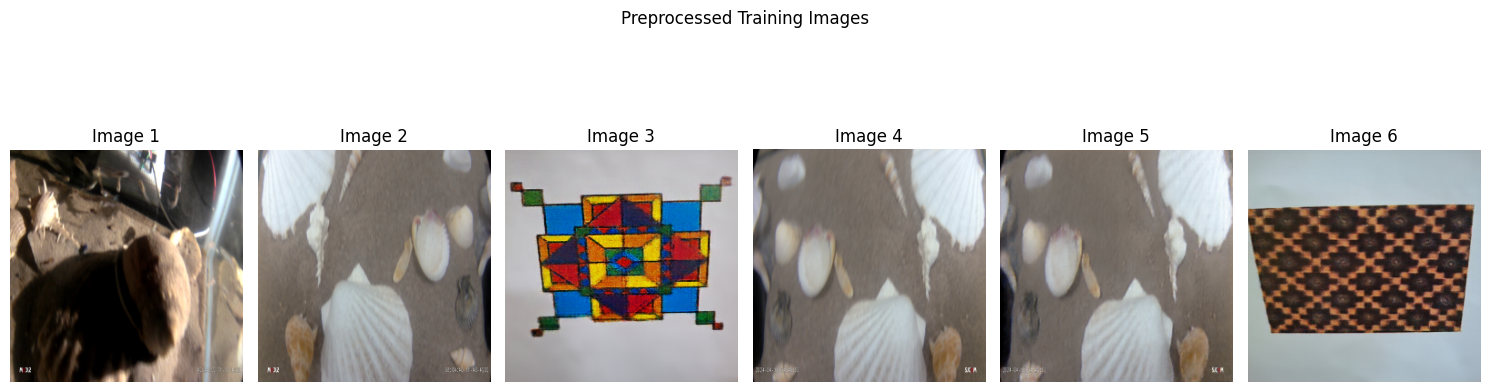

In [19]:
images = next(iter(train_loader))

images = images[:6]

images = images * 0.5 + 0.5

plt.figure(figsize=(15, 5))

for i in range(len(images)):

    img = images[i].permute(
        1, 2, 0
    ).numpy()

    plt.subplot(1, 6, i + 1)

    plt.imshow(img)

    plt.axis("off")

    plt.title(f"Image {i+1}")

plt.suptitle(
    "Preprocessed Training Images"
)

plt.tight_layout()

plt.show()

In [20]:
split_data = pd.DataFrame({

    "file_path":
        train_files +
        val_files +
        test_files,

    "split":
        ["train"] * len(train_files)
        +
        ["validation"] * len(val_files)
        +
        ["test"] * len(test_files)

})

split_data.to_csv(
    "dataset_splits_v1.csv",
    index=False
)

print("Dataset split file saved!")

Dataset split file saved!


In [21]:
import json

config = {

    "version": "v1.0",

    "image_size": IMAGE_SIZE,

    "normalization": {
        "mean": [0.5, 0.5, 0.5],
        "std": [0.5, 0.5, 0.5]
    },

    "augmentation": {
        "horizontal_flip": True,
        "probability": 0.5
    },

    "split": {
        "train": 0.70,
        "validation": 0.15,
        "test": 0.15
    },

    "random_seed": SEED,

    "notes":
        "Augmentation applied only to training data."
}

with open(
    "preprocessing_config_v1.json",
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )

print("Configuration saved successfully!")

Configuration saved successfully!


In [22]:
with open(
    "preprocessing_config_v1.json",
    "r"
) as f:

    saved_config = json.load(f)

print(
    json.dumps(
        saved_config,
        indent=4
    )
)

{
    "version": "v1.0",
    "image_size": 256,
    "normalization": {
        "mean": [
            0.5,
            0.5,
            0.5
        ],
        "std": [
            0.5,
            0.5,
            0.5
        ]
    },
    "augmentation": {
        "horizontal_flip": true,
        "probability": 0.5
    },
    "split": {
        "train": 0.7,
        "validation": 0.15,
        "test": 0.15
    },
    "random_seed": 42,
    "notes": "Augmentation applied only to training data."
}
